## Credit Risk Portfolio Analysis: Comparing Dependence Structures

**Problem:** Simulate 1 million scenarios for a portfolio of two BBB bonds to calculate expected credit loss and 99% VaR using two different dependence structures:
- Method A: Multivariate Gaussian (correlation = 0.5)
- Method B: Gaussian Copula (correlation = 0.5)

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

# Set random seed for reproducibility
np.random.seed(111111)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Data Setup

Define the rating transition probabilities and bond values from the table.

In [16]:
# Rating transition data for BBB bonds
ratings = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC', 'Default']
probabilities = np.array([0.02, 0.33, 5.95, 86.93, 5.30, 1.17, 0.12, 0.18]) / 100
values = np.array([109.37, 109.19, 108.66, 107.55, 102.02, 98.10, 83.64, 51.13])

# Create a DataFrame for better visualization
rating_data = pd.DataFrame({
    'Rating': ratings,
    'Probability (%)': probabilities * 100,
    'Value ($)': values
})

print("Rating Transition Data for BBB Bonds:")
print(rating_data.to_string(index=False))
print(f"\nInitial BBB Bond Value: ${values[3]:.2f}")
print(f"Sum of probabilities: {probabilities.sum():.4f}")

# Cumulative probabilities for inverse transform method
cumulative_probs = np.cumsum(probabilities)
print(f"\nCumulative probabilities:")
for i, (rating, cum_prob) in enumerate(zip(ratings, cumulative_probs)):
    print(f"{rating:8s}: {cum_prob:.6f}")

Rating Transition Data for BBB Bonds:
 Rating  Probability (%)  Value ($)
    AAA             0.02     109.37
     AA             0.33     109.19
      A             5.95     108.66
    BBB            86.93     107.55
     BB             5.30     102.02
      B             1.17      98.10
    CCC             0.12      83.64
Default             0.18      51.13

Initial BBB Bond Value: $107.55
Sum of probabilities: 1.0000

Cumulative probabilities:
AAA     : 0.000200
AA      : 0.003500
A       : 0.063000
BBB     : 0.932300
BB      : 0.985300
B       : 0.997000
CCC     : 0.998200
Default : 1.000000


## Method A: Multivariate Gaussian Approximation

Assume each bond's loss is approximately normal with mean and variance matched to the
single-name transition table. Correlate the two losses directly in Gaussian space
and aggregate the portfolio loss.

In [17]:
# Simulation parameters
n_simulations = 1_000_000
correlation = 0.5

# Calibrate a Gaussian approximation for single-bond losses
initial_bond_value = values[3]  # BBB rating is index 3
initial_portfolio_value = 2 * initial_bond_value
single_bond_losses = initial_bond_value - values
mean_loss_single = float(np.dot(probabilities, single_bond_losses))
var_loss_single = float(np.dot(probabilities, (single_bond_losses - mean_loss_single) ** 2))
std_loss_single = np.sqrt(var_loss_single)

# Correlation matrix (not covariance - we'll scale separately)
correlation_matrix_mvn = np.array([[1.0, correlation],
                                    [correlation, 1.0]])

# Cholesky decomposition: L @ L.T = correlation_matrix
L = np.linalg.cholesky(correlation_matrix_mvn)

# Generate independent standard normals
Z_indep = np.random.randn(n_simulations, 2)

# Apply Cholesky factor to induce correlation
Z_mvn = Z_indep @ L.T  # Shape: (n_simulations, 2)

# Scale by standard deviation and shift by mean
losses_mvn = mean_loss_single + std_loss_single * Z_mvn

# Aggregate portfolio outcomes
credit_losses_mvn = losses_mvn.sum(axis=1)
portfolio_values_mvn = initial_portfolio_value - credit_losses_mvn

print(f"Cholesky factor L:\n{L}")


Cholesky factor L:
[[1.        0.       ]
 [0.5       0.8660254]]


## Method B: Gaussian Copula on Rating Thresholds

Generate correlated standard normals, convert to uniforms, and apply the rating
transition thresholds so that the marginal rating distribution matches the
observed BBB transition matrix while dependence is governed by a Gaussian copula.

In [18]:
print("Method B: Gaussian Copula with Rating-Based Marginals")

# Step 1: Generate correlated standard normal variates using Cholesky
correlation_matrix = np.array([[1.0, correlation],
                               [correlation, 1.0]])

# Cholesky decomposition
L_copula = np.linalg.cholesky(correlation_matrix)

# Generate independent standard normals and apply Cholesky
Z_from_uniform = np.random.randn(n_simulations, 2)
Z_copula = Z_from_uniform @ L_copula.T

# Step 2: Map to uniforms using the standard normal CDF
U_copula = norm.cdf(Z_copula)

# Step 3: Transform uniforms to rating outcomes via inverse transform sampling
rating_idx1_copula = np.searchsorted(cumulative_probs, U_copula[:, 0], side='right')
rating_idx2_copula = np.searchsorted(cumulative_probs, U_copula[:, 1], side='right')

bond1_values_copula = values[rating_idx1_copula]
bond2_values_copula = values[rating_idx2_copula]

# Convert back to losses to analyse dependence
losses_copula = np.column_stack((initial_bond_value - bond1_values_copula,
                                 initial_bond_value - bond2_values_copula))
credit_losses_copula = losses_copula.sum(axis=1)
portfolio_values_copula = initial_portfolio_value - credit_losses_copula



Method B: Gaussian Copula with Rating-Based Marginals


## Results Analysis

Calculate expected credit loss and 99% VaR for both methods.

In [19]:
# Calculate metrics for Method A
expected_loss_mvn = np.mean(credit_losses_mvn)
var_99_mvn = np.percentile(credit_losses_mvn, 99)

# Calculate metrics for Method B
expected_loss_copula = np.mean(credit_losses_copula)
var_99_copula = np.percentile(credit_losses_copula, 99)

# Empirical dependence diagnostics
loss_corr_mvn = np.corrcoef(losses_mvn[:, 0], losses_mvn[:, 1])[0, 1]
loss_corr_copula = np.corrcoef(losses_copula[:, 0], losses_copula[:, 1])[0, 1]

# Use a subsample for rank correlation to keep computations tractable
rng_diag = np.random.default_rng(20251025)
diagnostic_idx = rng_diag.choice(n_simulations, size=200_000, replace=False)
spearman_mvn = stats.spearmanr(losses_mvn[diagnostic_idx, 0], losses_mvn[diagnostic_idx, 1]).correlation
spearman_copula = stats.spearmanr(losses_copula[diagnostic_idx, 0], losses_copula[diagnostic_idx, 1]).correlation

# Create results summary
results_df = pd.DataFrame({
    'Method': ['A: Multivariate Gaussian Approx.', 'B: Gaussian Copula'],
    'Expected Credit Loss ($)': [expected_loss_mvn, expected_loss_copula],
    '99% VaR ($)': [var_99_mvn, var_99_copula],
    'Linear Corr (loss1, loss2)': [loss_corr_mvn, loss_corr_copula],
    'Spearman Corr (loss1, loss2)': [spearman_mvn, spearman_copula]
})

print("\n" + "=" * 70)
print("CREDIT RISK ANALYSIS RESULTS")
print("=" * 70)
print(f"\nInitial Portfolio Value: ${initial_portfolio_value:.2f}")
print(f"Number of Simulations: {n_simulations:,}")
print(f"Latent Correlation Parameter: {correlation}")
print("\n" + results_df.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))
print("=" * 70)




CREDIT RISK ANALYSIS RESULTS

Initial Portfolio Value: $215.10
Number of Simulations: 1,000,000
Latent Correlation Parameter: 0.5

                          Method  Expected Credit Loss ($)  99% VaR ($)  Linear Corr (loss1, loss2)  Spearman Corr (loss1, loss2)
A: Multivariate Gaussian Approx.                    0.9251      13.0151                      0.5015                        0.4849
              B: Gaussian Copula                    0.9284      14.9800                      0.2033                        0.2677


## Statistical Summary

In [20]:
stats_summary = pd.DataFrame({
    'Metric': ['Mean Loss', 'Median Loss', 'Std Dev', 'Skewness', 'Kurtosis', 
               '95% VaR', '99% VaR', '99.9% VaR', 'Min Loss', 'Max Loss'],
    'Method A': [
        expected_loss_mvn,
        np.median(credit_losses_mvn),
        np.std(credit_losses_mvn),
        stats.skew(credit_losses_mvn),
        stats.kurtosis(credit_losses_mvn),
        np.percentile(credit_losses_mvn, 95),
        var_99_mvn,
        np.percentile(credit_losses_mvn, 99.9),
        np.min(credit_losses_mvn),
        np.max(credit_losses_mvn)
    ],
    'Method B': [
        expected_loss_copula,
        np.median(credit_losses_copula),
        np.std(credit_losses_copula),
        stats.skew(credit_losses_copula),
        stats.kurtosis(credit_losses_copula),
        np.percentile(credit_losses_copula, 95),
        var_99_copula,
        np.percentile(credit_losses_copula, 99.9),
        np.min(credit_losses_copula),
        np.max(credit_losses_copula)
    ]
})

stats_summary['Difference (B-A)'] = stats_summary['Method B'] - stats_summary['Method A']
stats_summary['% Diff'] = (stats_summary['Difference (B-A)'] / stats_summary['Method A'].abs()) * 100

print(stats_summary.to_string(index=False))

     Metric   Method A   Method B  Difference (B-A)        % Diff
  Mean Loss   0.925088   0.928422          0.003334  3.604444e-01
Median Loss   0.925416   0.000000         -0.925416 -1.000000e+02
    Std Dev   5.184416   4.690709         -0.493706 -9.522892e+00
   Skewness   0.000488   9.901917          9.901428  2.027890e+06
   Kurtosis   0.005166 136.957220        136.952054  2.650790e+06
    95% VaR   9.457193   5.530000         -3.927193 -4.152599e+01
    99% VaR  13.015075  14.980000          1.964925  1.509730e+01
  99.9% VaR  16.948367  61.950000         45.001633  2.655219e+02
   Min Loss -23.999319  -3.640000         20.359319  8.483290e+01
   Max Loss  25.557397 112.840000         87.282603  3.415160e+02


## Visualizations

Generate publication-quality figures and save them to the blog images directory.

Saved: 001_credit_risk_comparison_overview.png


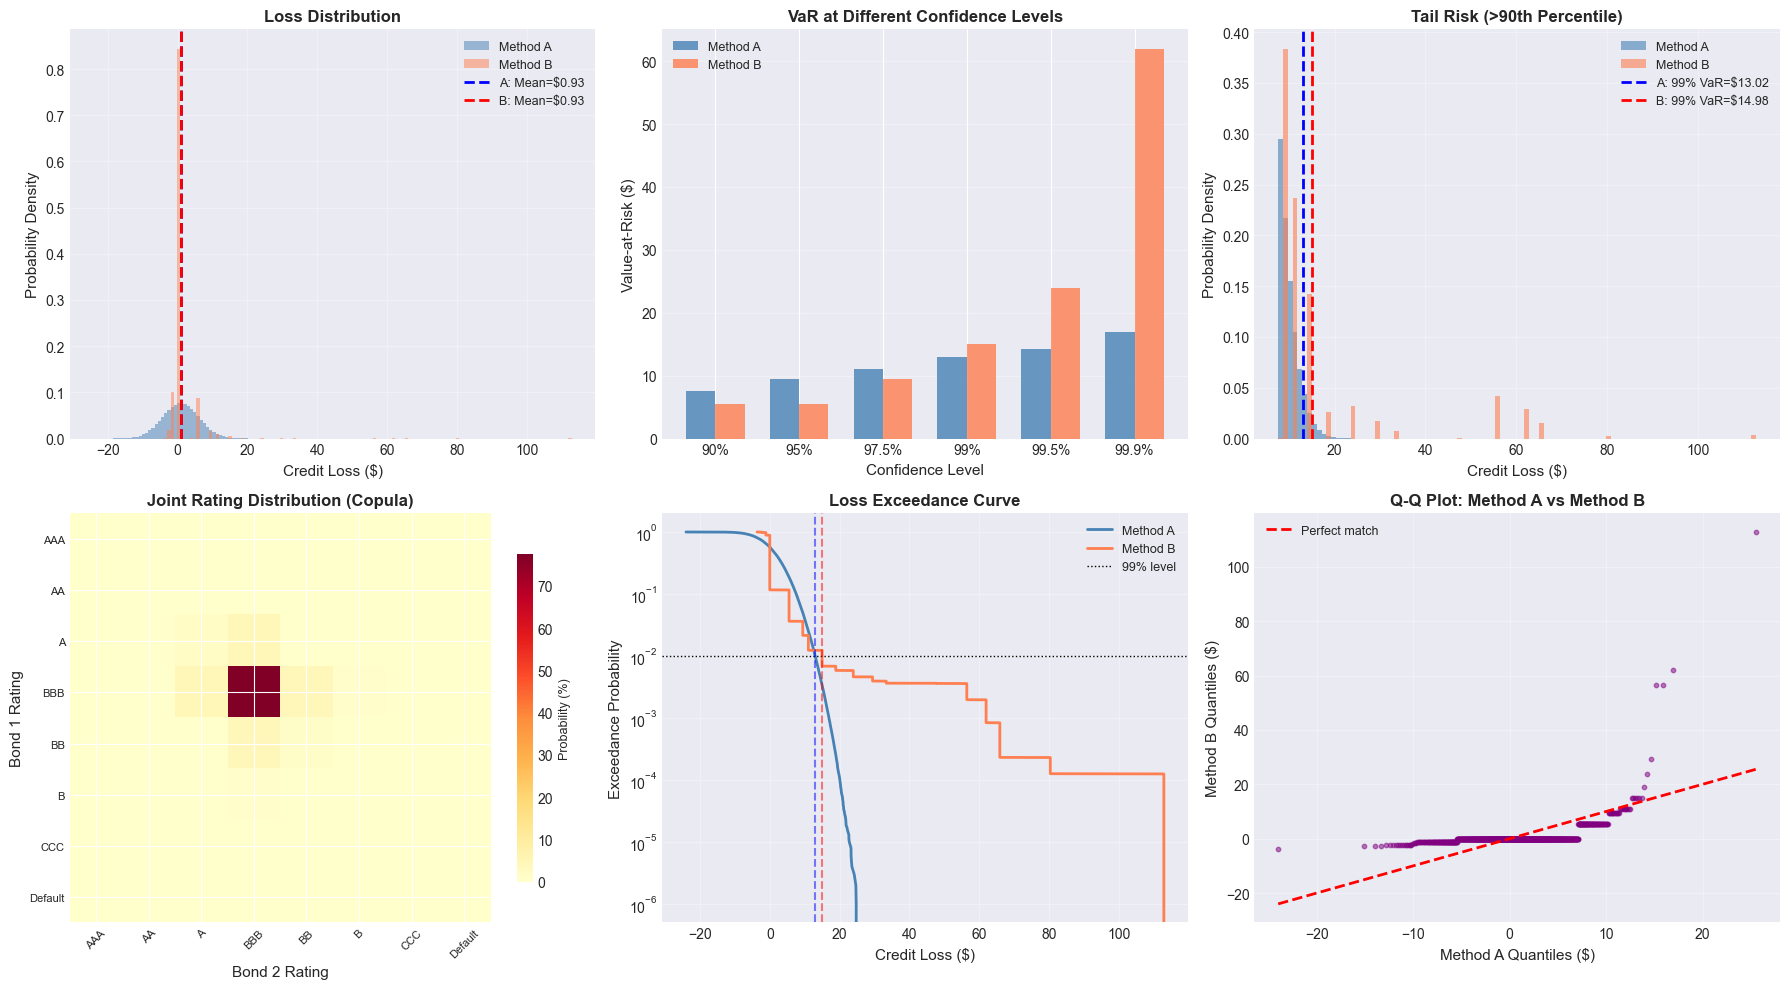

In [21]:
from pathlib import Path

# Create output directory for blog images
output_dir = Path('./images_project_2_Gerard_Wu')
output_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Loss distribution histogram
ax1 = axes[0, 0]
bins = np.linspace(min(credit_losses_mvn.min(), credit_losses_copula.min()), 
                   max(credit_losses_mvn.max(), credit_losses_copula.max()), 150)
ax1.hist(credit_losses_mvn, bins=bins, alpha=0.5, label='Method A', color='steelblue', density=True)
ax1.hist(credit_losses_copula, bins=bins, alpha=0.5, label='Method B', color='coral', density=True)
ax1.axvline(expected_loss_mvn, color='blue', linestyle='--', linewidth=2, label=f'A: Mean=${expected_loss_mvn:.2f}')
ax1.axvline(expected_loss_copula, color='red', linestyle='--', linewidth=2, label=f'B: Mean=${expected_loss_copula:.2f}')
ax1.set_xlabel('Credit Loss ($)', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('Loss Distribution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. VaR levels comparison
ax2 = axes[0, 1]
percentiles = [90, 95, 97.5, 99, 99.5, 99.9]
var_mvn = [np.percentile(credit_losses_mvn, p) for p in percentiles]
var_copula = [np.percentile(credit_losses_copula, p) for p in percentiles]
x_pos = np.arange(len(percentiles))
width = 0.35
ax2.bar(x_pos - width/2, var_mvn, width, label='Method A', color='steelblue', alpha=0.8)
ax2.bar(x_pos + width/2, var_copula, width, label='Method B', color='coral', alpha=0.8)
ax2.set_xlabel('Confidence Level', fontsize=11)
ax2.set_ylabel('Value-at-Risk ($)', fontsize=11)
ax2.set_title('VaR at Different Confidence Levels', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{p}%' for p in percentiles])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Tail risk (losses > 90th percentile)
ax3 = axes[0, 2]
tail_cutoff = np.percentile(credit_losses_mvn, 90)
tail_mvn = credit_losses_mvn[credit_losses_mvn >= tail_cutoff]
tail_copula = credit_losses_copula[credit_losses_copula >= tail_cutoff]
bins_tail = np.linspace(tail_cutoff, max(tail_mvn.max(), tail_copula.max()), 100)
ax3.hist(tail_mvn, bins=bins_tail, alpha=0.6, label='Method A', color='steelblue', density=True)
ax3.hist(tail_copula, bins=bins_tail, alpha=0.6, label='Method B', color='coral', density=True)
ax3.axvline(var_99_mvn, color='blue', linestyle='--', linewidth=2, label=f'A: 99% VaR=${var_99_mvn:.2f}')
ax3.axvline(var_99_copula, color='red', linestyle='--', linewidth=2, label=f'B: 99% VaR=${var_99_copula:.2f}')
ax3.set_xlabel('Credit Loss ($)', fontsize=11)
ax3.set_ylabel('Probability Density', fontsize=11)
ax3.set_title('Tail Risk (>90th Percentile)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Joint rating distribution (Copula method only - MVN uses continuous losses)
ax4 = axes[1, 0]
# Create joint frequency matrix for the copula method
joint_freq = np.zeros((len(ratings), len(ratings)))
for i in range(n_simulations):
    joint_freq[rating_idx1_copula[i], rating_idx2_copula[i]] += 1
joint_freq = joint_freq / n_simulations * 100  # Convert to percentage

im = ax4.imshow(joint_freq, cmap='YlOrRd', aspect='auto')
ax4.set_xlabel('Bond 2 Rating', fontsize=11)
ax4.set_ylabel('Bond 1 Rating', fontsize=11)
ax4.set_title('Joint Rating Distribution (Copula)', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(ratings)))
ax4.set_xticklabels(ratings, rotation=45, fontsize=8)
ax4.set_yticks(range(len(ratings)))
ax4.set_yticklabels(ratings, fontsize=8)
cbar = plt.colorbar(im, ax=ax4, shrink=0.8)
cbar.set_label('Probability (%)', fontsize=9)

# 5. Exceedance probability
ax5 = axes[1, 1]
sorted_mvn = np.sort(credit_losses_mvn)
sorted_copula = np.sort(credit_losses_copula)
exceedance_mvn = 1 - np.arange(1, len(sorted_mvn) + 1) / len(sorted_mvn)
exceedance_copula = 1 - np.arange(1, len(sorted_copula) + 1) / len(sorted_copula)
ax5.plot(sorted_mvn, exceedance_mvn, label='Method A', color='steelblue', linewidth=2)
ax5.plot(sorted_copula, exceedance_copula, label='Method B', color='coral', linewidth=2)
ax5.axhline(0.01, color='black', linestyle=':', linewidth=1, label='99% level')
ax5.axvline(var_99_mvn, color='blue', linestyle='--', alpha=0.5)
ax5.axvline(var_99_copula, color='red', linestyle='--', alpha=0.5)
ax5.set_xlabel('Credit Loss ($)', fontsize=11)
ax5.set_ylabel('Exceedance Probability', fontsize=11)
ax5.set_title('Loss Exceedance Curve', fontsize=12, fontweight='bold')
ax5.set_yscale('log')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Q-Q plot
ax6 = axes[1, 2]
quantiles = np.linspace(0, 1, 1000)
q_mvn = np.percentile(credit_losses_mvn, quantiles * 100)
q_copula = np.percentile(credit_losses_copula, quantiles * 100)
ax6.scatter(q_mvn, q_copula, alpha=0.5, s=10, color='purple')
ax6.plot([q_mvn.min(), q_mvn.max()], [q_mvn.min(), q_mvn.max()], 
         'r--', linewidth=2, label='Perfect match')
ax6.set_xlabel('Method A Quantiles ($)', fontsize=11)
ax6.set_ylabel('Method B Quantiles ($)', fontsize=11)
ax6.set_title('Q-Q Plot: Method A vs Method B', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / '001_credit_risk_comparison_overview.png', dpi=300, bbox_inches='tight')
print(f"Saved: 001_credit_risk_comparison_overview.png")
plt.show()

## Additional Blog Figures

Create individual high-quality figures for the blog post.

Saved: 003_loss_distribution.png


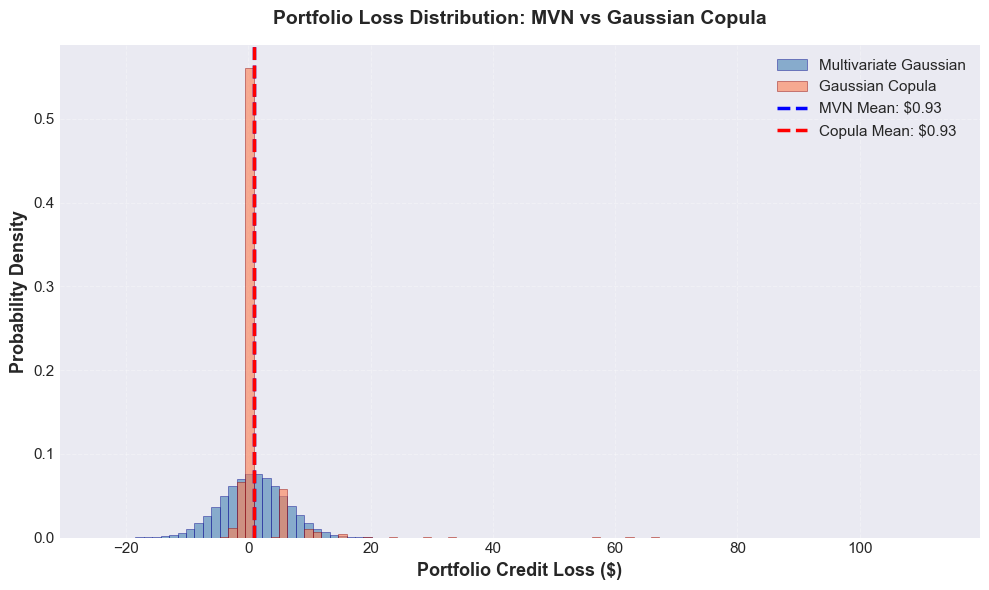

In [22]:
# Figure 3: Loss Distribution Comparison (standalone)
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(min(credit_losses_mvn.min(), credit_losses_copula.min()), 
                   max(credit_losses_mvn.max(), credit_losses_copula.max()), 100)
ax.hist(credit_losses_mvn, bins=bins, alpha=0.6, label='Multivariate Gaussian', 
        color='steelblue', density=True, edgecolor='darkblue', linewidth=0.5)
ax.hist(credit_losses_copula, bins=bins, alpha=0.6, label='Gaussian Copula', 
        color='coral', density=True, edgecolor='darkred', linewidth=0.5)

ax.axvline(expected_loss_mvn, color='blue', linestyle='--', linewidth=2.5, 
           label=f'MVN Mean: ${expected_loss_mvn:.2f}')
ax.axvline(expected_loss_copula, color='red', linestyle='--', linewidth=2.5, 
           label=f'Copula Mean: ${expected_loss_copula:.2f}')

ax.set_xlabel('Portfolio Credit Loss ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
ax.set_title('Portfolio Loss Distribution: MVN vs Gaussian Copula', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(output_dir / '003_loss_distribution.png', dpi=300, bbox_inches='tight')
print(f"Saved: 003_loss_distribution.png")
plt.show()

Saved: 004_var_comparison.png


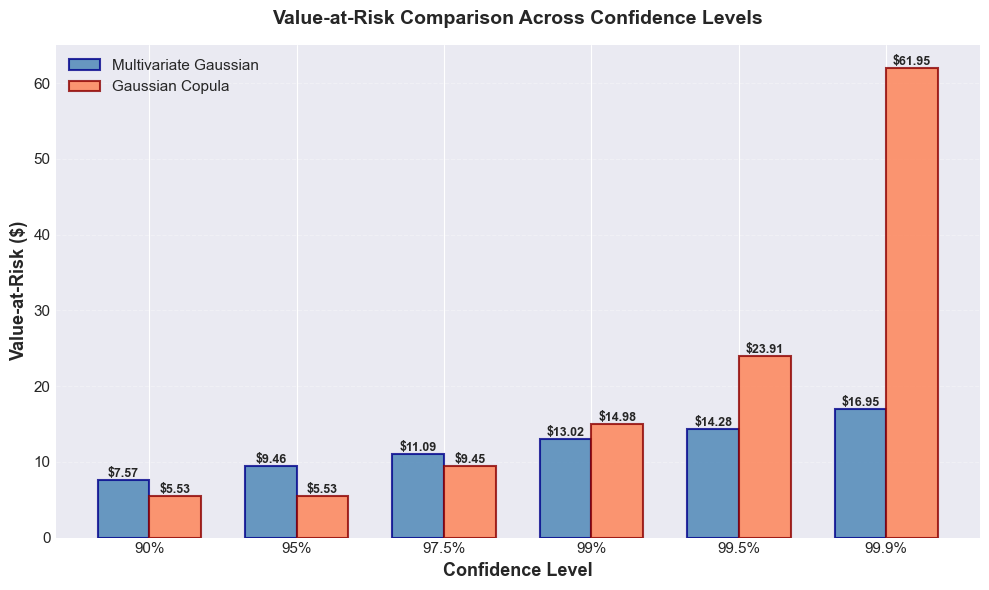

In [23]:
# Figure 4: VaR Comparison
fig, ax = plt.subplots(figsize=(10, 6))

percentiles = [90, 95, 97.5, 99, 99.5, 99.9]
var_mvn_plot = [np.percentile(credit_losses_mvn, p) for p in percentiles]
var_copula_plot = [np.percentile(credit_losses_copula, p) for p in percentiles]
x_pos = np.arange(len(percentiles))
width = 0.35

bars1 = ax.bar(x_pos - width/2, var_mvn_plot, width, label='Multivariate Gaussian', 
               color='steelblue', alpha=0.8, edgecolor='darkblue', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, var_copula_plot, width, label='Gaussian Copula', 
               color='coral', alpha=0.8, edgecolor='darkred', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Confidence Level', fontsize=13, fontweight='bold')
ax.set_ylabel('Value-at-Risk ($)', fontsize=13, fontweight='bold')
ax.set_title('Value-at-Risk Comparison Across Confidence Levels', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{p}%' for p in percentiles], fontsize=11)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(output_dir / '004_var_comparison.png', dpi=300, bbox_inches='tight')
print(f"Saved: 004_var_comparison.png")
plt.show()

Saved: 005_tail_risk.png


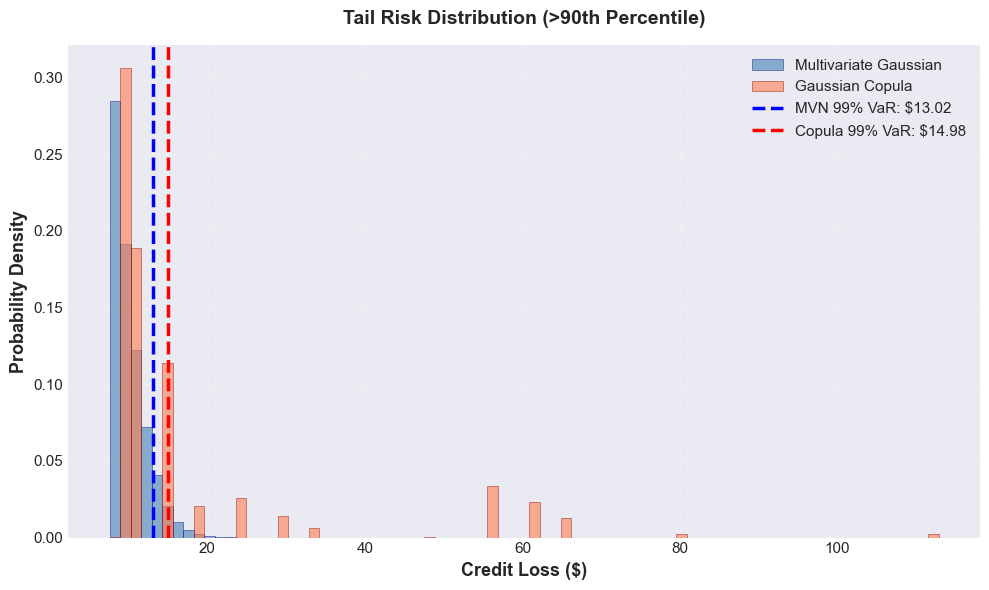

In [24]:
# Figure 5: Tail Risk Focus
fig, ax = plt.subplots(figsize=(10, 6))

tail_cutoff = np.percentile(credit_losses_mvn, 90)
tail_mvn = credit_losses_mvn[credit_losses_mvn >= tail_cutoff]
tail_copula = credit_losses_copula[credit_losses_copula >= tail_cutoff]
bins_tail = np.linspace(tail_cutoff, max(tail_mvn.max(), tail_copula.max()), 80)

ax.hist(tail_mvn, bins=bins_tail, alpha=0.6, label='Multivariate Gaussian', 
        color='steelblue', density=True, edgecolor='darkblue', linewidth=0.5)
ax.hist(tail_copula, bins=bins_tail, alpha=0.6, label='Gaussian Copula', 
        color='coral', density=True, edgecolor='darkred', linewidth=0.5)

ax.axvline(var_99_mvn, color='blue', linestyle='--', linewidth=2.5, 
           label=f'MVN 99% VaR: ${var_99_mvn:.2f}')
ax.axvline(var_99_copula, color='red', linestyle='--', linewidth=2.5, 
           label=f'Copula 99% VaR: ${var_99_copula:.2f}')

ax.set_xlabel('Credit Loss ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
ax.set_title('Tail Risk Distribution (>90th Percentile)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(output_dir / '005_tail_risk.png', dpi=300, bbox_inches='tight')
print(f"Saved: 005_tail_risk.png")
plt.show()

## Portfolio Size Scaling Analysis

Analyze how the 99th percentile of expected credit loss scales as we increase the number of bonds in the portfolio from 1 to 100.

In [25]:
# Portfolio size scaling analysis: 99th percentile VaR vs number of bonds
# Using both Method A (MVN) and Method B (Gaussian Copula)

def simulate_portfolio_var(n_bonds, n_sims=100_000, correlation=0.5, method='copula'):
    """
    Simulate portfolio credit losses and return the 99th percentile VaR.
    
    Parameters
    ----------
    n_bonds : int
        Number of bonds in the portfolio
    n_sims : int
        Number of Monte Carlo simulations
    correlation : float
        Pairwise correlation between bonds
    method : str
        'copula' for Gaussian Copula, 'mvn' for Multivariate Gaussian
    
    Returns
    -------
    float
        99th percentile of portfolio credit loss
    """
    # Build correlation matrix (equicorrelation structure)
    corr_matrix = np.full((n_bonds, n_bonds), correlation)
    np.fill_diagonal(corr_matrix, 1.0)
    
    # Cholesky decomposition
    L = np.linalg.cholesky(corr_matrix)
    
    # Generate correlated standard normals
    Z_indep = np.random.randn(n_sims, n_bonds)
    Z_corr = Z_indep @ L.T
    
    if method == 'copula':
        # Transform to uniforms
        U = norm.cdf(Z_corr)
        # Map to rating outcomes
        rating_indices = np.searchsorted(cumulative_probs, U, side='right')
        bond_values = values[rating_indices]
        losses = initial_bond_value - bond_values
    else:  # MVN approximation
        losses = mean_loss_single + std_loss_single * Z_corr
    
    # Aggregate portfolio loss
    portfolio_losses = losses.sum(axis=1)
    
    return np.percentile(portfolio_losses, 99)

# Range of portfolio sizes to analyze
bond_counts = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100]

# Store results
var_99_copula_by_size = []
var_99_mvn_by_size = []

print("Computing 99% VaR for different portfolio sizes...")
print("-" * 50)

np.random.seed(42)  # For reproducibility

for n_bonds in bond_counts:
    # Gaussian Copula method
    var_copula = simulate_portfolio_var(n_bonds, n_sims=200_000, method='copula')
    var_99_copula_by_size.append(var_copula)
    
    # MVN method
    var_mvn = simulate_portfolio_var(n_bonds, n_sims=200_000, method='mvn')
    var_99_mvn_by_size.append(var_mvn)
    
    print(f"n={n_bonds:3d} bonds | Copula 99% VaR: ${var_copula:10.2f} | MVN 99% VaR: ${var_mvn:10.2f}")

print("-" * 50)
print("Done!")

Computing 99% VaR for different portfolio sizes...
--------------------------------------------------
n=  1 bonds | Copula 99% VaR: $      9.45 | MVN 99% VaR: $      7.41
n=  2 bonds | Copula 99% VaR: $     14.98 | MVN 99% VaR: $     13.00
n=  3 bonds | Copula 99% VaR: $     20.51 | MVN 99% VaR: $     18.38
n=  5 bonds | Copula 99% VaR: $     34.98 | MVN 99% VaR: $     29.25
n= 10 bonds | Copula 99% VaR: $     76.93 | MVN 99% VaR: $     56.03
n= 15 bonds | Copula 99% VaR: $    106.37 | MVN 99% VaR: $     83.26
n= 10 bonds | Copula 99% VaR: $     76.93 | MVN 99% VaR: $     56.03
n= 15 bonds | Copula 99% VaR: $    106.37 | MVN 99% VaR: $     83.26
n= 20 bonds | Copula 99% VaR: $    136.15 | MVN 99% VaR: $    109.50
n= 20 bonds | Copula 99% VaR: $    136.15 | MVN 99% VaR: $    109.50
n= 30 bonds | Copula 99% VaR: $    196.77 | MVN 99% VaR: $    162.66
n= 30 bonds | Copula 99% VaR: $    196.77 | MVN 99% VaR: $    162.66
n= 50 bonds | Copula 99% VaR: $    319.97 | MVN 99% VaR: $    270.98
n

In [26]:
# Create results DataFrame
scaling_results = pd.DataFrame({
    'Number of Bonds': bond_counts,
    'Copula 99% VaR ($)': var_99_copula_by_size,
    'MVN 99% VaR ($)': var_99_mvn_by_size,
    'Copula VaR per Bond ($)': [v/n for v, n in zip(var_99_copula_by_size, bond_counts)],
    'MVN VaR per Bond ($)': [v/n for v, n in zip(var_99_mvn_by_size, bond_counts)]
})

print("\nPortfolio Size Scaling Results:")
print("=" * 80)
print(scaling_results.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print("=" * 80)


Portfolio Size Scaling Results:
 Number of Bonds  Copula 99% VaR ($)  MVN 99% VaR ($)  Copula VaR per Bond ($)  MVN VaR per Bond ($)
               1                9.45             7.41                     9.45                  7.41
               2               14.98            13.00                     7.49                  6.50
               3               20.51            18.38                     6.84                  6.13
               5               34.98            29.25                     7.00                  5.85
              10               76.93            56.03                     7.69                  5.60
              15              106.37            83.26                     7.09                  5.55
              20              136.15           109.50                     6.81                  5.47
              30              196.77           162.66                     6.56                  5.42
              50              319.97           270.98     

Saved: 006_var_vs_portfolio_size.png


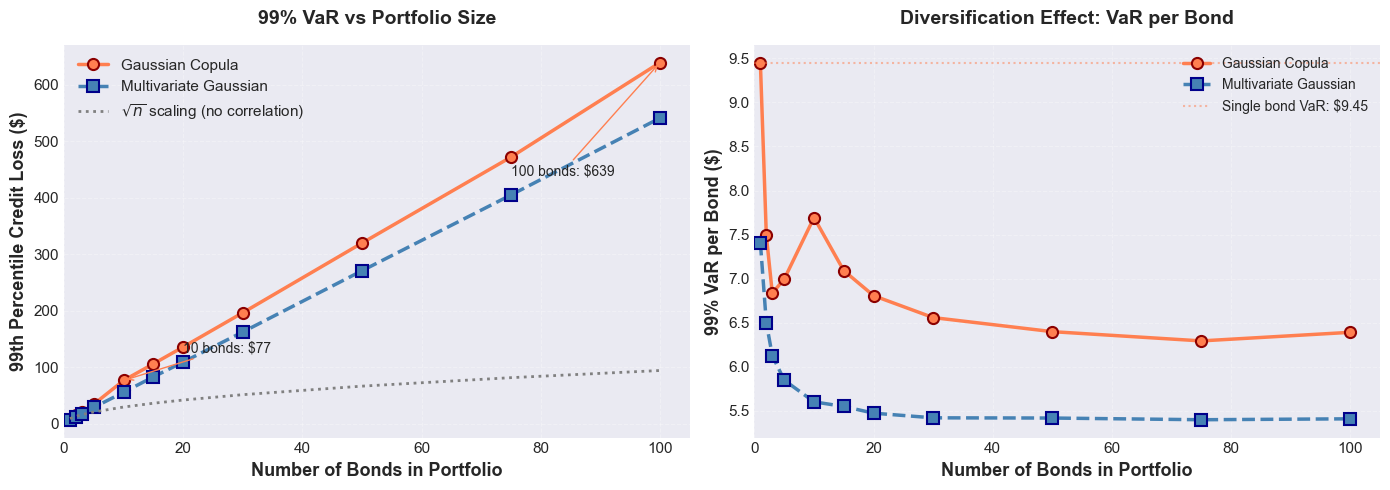

In [27]:
# Figure: 99% VaR vs Number of Bonds
from pathlib import Path
output_dir = Path('./images_project_2_Gerard_Wu')
output_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Absolute 99% VaR
ax1 = axes[0]
ax1.plot(bond_counts, var_99_copula_by_size, 'o-', color='coral', linewidth=2.5, 
         markersize=8, label='Gaussian Copula', markeredgecolor='darkred', markeredgewidth=1.5)
ax1.plot(bond_counts, var_99_mvn_by_size, 's--', color='steelblue', linewidth=2.5, 
         markersize=8, label='Multivariate Gaussian', markeredgecolor='darkblue', markeredgewidth=1.5)

# Add reference line for perfect diversification (sqrt scaling)
var_1_bond_copula = var_99_copula_by_size[0]
sqrt_scaling = [var_1_bond_copula * np.sqrt(n) for n in bond_counts]
ax1.plot(bond_counts, sqrt_scaling, ':', color='gray', linewidth=2, 
         label=r'$\sqrt{n}$ scaling (no correlation)')

ax1.set_xlabel('Number of Bonds in Portfolio', fontsize=13, fontweight='bold')
ax1.set_ylabel('99th Percentile Credit Loss ($)', fontsize=13, fontweight='bold')
ax1.set_title('99% VaR vs Portfolio Size', fontsize=14, fontweight='bold', pad=15)
ax1.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=11)
ax1.set_xlim(0, 105)

# Add annotations for key points
ax1.annotate(f'10 bonds: ${var_99_copula_by_size[bond_counts.index(10)]:.0f}', 
             xy=(10, var_99_copula_by_size[bond_counts.index(10)]),
             xytext=(20, var_99_copula_by_size[bond_counts.index(10)] + 50),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='coral'))
ax1.annotate(f'100 bonds: ${var_99_copula_by_size[-1]:.0f}', 
             xy=(100, var_99_copula_by_size[-1]),
             xytext=(75, var_99_copula_by_size[-1] - 200),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='coral'))

# Right panel: VaR per bond (diversification benefit)
ax2 = axes[1]
var_per_bond_copula = [v/n for v, n in zip(var_99_copula_by_size, bond_counts)]
var_per_bond_mvn = [v/n for v, n in zip(var_99_mvn_by_size, bond_counts)]

ax2.plot(bond_counts, var_per_bond_copula, 'o-', color='coral', linewidth=2.5, 
         markersize=8, label='Gaussian Copula', markeredgecolor='darkred', markeredgewidth=1.5)
ax2.plot(bond_counts, var_per_bond_mvn, 's--', color='steelblue', linewidth=2.5, 
         markersize=8, label='Multivariate Gaussian', markeredgecolor='darkblue', markeredgewidth=1.5)

# Reference: single bond VaR
ax2.axhline(var_per_bond_copula[0], color='coral', linestyle=':', alpha=0.5, 
            label=f'Single bond VaR: ${var_per_bond_copula[0]:.2f}')

ax2.set_xlabel('Number of Bonds in Portfolio', fontsize=13, fontweight='bold')
ax2.set_ylabel('99% VaR per Bond ($)', fontsize=13, fontweight='bold')
ax2.set_title('Diversification Effect: VaR per Bond', fontsize=14, fontweight='bold', pad=15)
ax2.legend(fontsize=10, loc='upper right', framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=11)
ax2.set_xlim(0, 105)

plt.tight_layout()
plt.savefig(output_dir / '006_var_vs_portfolio_size.png', dpi=300, bbox_inches='tight')
print(f"Saved: 006_var_vs_portfolio_size.png")
plt.show()